# Research Trends Analysis on AI and ML of 2026

In [3]:
import requests
import pandas as pd
import time #Used here to add delays between requests, respecting API rate limits.
import xml.etree.ElementTree as ET
#Parses XML responses from the ArXiv API. ArXiv returns Atom XML feeds, so this library extracts data from them.
from tqdm import tqdm
#Adds a progress bar to loops, making it easier to track progress when fetching large batches of papers.

BASE_URL = "http://export.arxiv.org/api/query"


'''
Defines a function to fetch papers from ArXiv.

Parameters:

search_query: What to search for (default is “machine learning”).

max_results: Total number of papers to fetch.

batch_size: How many papers to fetch per request (ArXiv limits batch sizes).

delay: Pause between requests to avoid overwhelming the API.
'''
def fetch_arxiv_data(search_query="all:machine learning",
                     max_results=1000,
                     batch_size=100,
                     delay=3):
    
    """
    Fetch data from ArXiv API in batches.
    """

    all_entries = [] #Initializes an empty list to store all paper entries.

    '''
    Loops from 0 up to max_results in steps of batch_size.

    tqdm wraps the loop to show a progress bar.

    Example: If max_results=1000 and batch_size=100, it will run 10 iterations.
    '''
    for start in tqdm(range(0, max_results, batch_size)):
        params = {
            "search_query": search_query,
            "start": start,
            "max_results": batch_size,
            "sortBy": "submittedDate",
            "sortOrder": "descending"
        }

        response = requests.get(BASE_URL, params=params)

        if response.status_code != 200:
            print(f"Error at start={start}: {response.status_code}")
            continue

        '''
        Converts the XML response into a tree structure.

        Defines the Atom namespace (needed because XML tags are namespaced).
        '''
        root = ET.fromstring(response.content)

        namespace = {"atom": "http://www.w3.org/2005/Atom"}

        for entry in root.findall("atom:entry", namespace):
            paper = {}

            paper["id"] = entry.find("atom:id", namespace).text
            paper["title"] = entry.find("atom:title", namespace).text.strip()
            paper["summary"] = entry.find("atom:summary", namespace).text.strip()

            paper["published"] = entry.find("atom:published", namespace).text
            paper["updated"] = entry.find("atom:updated", namespace).text

            # Authors
            authors = entry.findall("atom:author", namespace)
            paper["authors"] = ", ".join([
                author.find("atom:name", namespace).text for author in authors
            ])

            # Categories
            '''
            Extracts subject categories (e.g., cs.AI, cs.LG).

            Joins them into a comma-separated string.
            '''
            categories = entry.findall("atom:category", namespace)
            paper["categories"] = ", ".join([
                cat.attrib["term"] for cat in categories
            ])

            all_entries.append(paper)

        time.sleep(delay)  # respect API rate limits

    return pd.DataFrame(all_entries)


def save_to_csv(df, filename="arxiv_data.csv"):
    df.to_csv(filename, index=False)
    print(f"Saved {len(df)} records to {filename}")


if __name__ == "__main__":
    df = fetch_arxiv_data(
        search_query="cat:cs.AI OR cat:cs.LG OR cat:cs.CL",
        max_results=1500,
        batch_size=100
    )

    save_to_csv(df)

100%|██████████| 15/15 [01:18<00:00,  5.26s/it]

Saved 1500 records to arxiv_data.csv


# Data Cleaning + NLP Pipeline

In [5]:
import pandas as pd
import re
import nltk
import spacy
import yake
from tqdm import tqdm

# Download NLTK resources (run once)
nltk.download('stopwords')
from nltk.corpus import stopwords

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

STOPWORDS = set(stopwords.words('english'))

# =========================
# 1. LOAD DATA
# =========================
file_path = r"C:\Users\abc\Downloads\arxiv_data.csv"
#df = pd.read_csv(file_path)
df = pd.read_csv(file_path, encoding='utf-8', encoding_errors='ignore')

# =========================
# 2. CLEANING FUNCTIONS
# =========================

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    
    # Remove special characters / numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# Apply cleaning
df["clean_summary"] = df["summary"].apply(clean_text)
df["clean_title"] = df["title"].apply(clean_text)

# =========================
# 3. TOKENIZATION + LEMMATIZATION
# =========================

'''
Uses spaCy to tokenize text.

Keeps only alphabetic tokens.

Removes stopwords.

Filters out very short words (length ≤ 2).

Converts words to their lemma (base form, e.g., “running” → “run”).
'''
def tokenize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha
        and token.text not in STOPWORDS
        and len(token.text) > 2
    ]
    return tokens


tqdm.pandas()
df["tokens"] = df["clean_summary"].progress_apply(tokenize)

# =========================
# 4. KEYWORD EXTRACTION (YAKE)
# =========================

'''
Configures YAKE to extract keywords.

n=2 → allows up to bigrams (two-word phrases).

top=5 → extracts top 5 keywords per document.
'''
kw_extractor = yake.KeywordExtractor(
    lan="en",
    n=2,           # max n-gram size
    top=5          # top keywords
)

def extract_keywords(text):
    if not text:
        return []
    keywords = kw_extractor.extract_keywords(text)
    return [kw[0] for kw in keywords]


df["keywords"] = df["clean_summary"].progress_apply(extract_keywords)

# =========================
# 5. CATEGORY CLEANING
# =========================

def extract_primary_category(cat):
    if pd.isna(cat):
        return None
    return cat.split(",")[0].strip()

df["primary_category"] = df["categories"].apply(extract_primary_category)

# =========================
# 6. DATE FEATURES
# =========================

df["published"] = pd.to_datetime(df["published"])
df["year"] = df["published"].dt.year
df["month"] = df["published"].dt.month

# =========================
# 7. SAVE CLEAN DATA
# =========================

output_path = r"C:\Users\abc\Downloads\arxiv_cleaned.csv"
df.to_csv(output_path, index=False)

print("✅ Pipeline complete. Cleaned data saved.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 1500/1500 [00:39<00:00, 38.29it/s]


✅ Pipeline complete. Cleaned data saved.


# Semantic + Trend Intelligence Layer
## STEP 1 — Load & Validate (Production-safe)

In [6]:
import pandas as pd
import ast 
# Provides literal_eval, which safely evaluates strings that look like Python objects 
# #(like lists or dictionaries) without executing arbitrary code.

file_path = r"C:\Users\abc\Downloads\arxiv_cleaned.csv"

df = pd.read_csv(file_path, encoding="utf-8")

# Convert stringified lists safely
'''
Defines a helper function to convert stringified lists back into actual Python lists.

Uses ast.literal_eval (safe, unlike eval) to parse strings like "['AI', 'learning']".

If parsing fails (e.g., malformed string), it returns an empty list instead of crashing.
'''
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return []


#This is crucial because when saving to CSV, lists are stored as strings. 
# Without conversion, you couldn’t easily manipulate them later.
df["tokens"] = df["tokens"].apply(safe_eval)
df["keywords"] = df["keywords"].apply(safe_eval)

# Basic sanity checks
assert "clean_summary" in df.columns
assert df["clean_summary"].notna().sum() > 0

print("Dataset shape:", df.shape)

Dataset shape: (1500, 14)


## STEP 2 — Build Document Representation (TF-IDF)

In [7]:
'''TF‑IDF = Term Frequency–Inverse Document Frequency, 
a common technique in NLP to measure how important a word is in a document 
relative to the whole corpus.
'''

from sklearn.feature_extraction.text import TfidfVectorizer


'''
Creates a TF‑IDF vectorizer with specific settings:

max_features=5000 → Keep only the 5,000 most important terms. Prevents the matrix from exploding in size.

ngram_range=(1,2) → Includes both single words (unigrams) and two‑word phrases (bigrams). This captures context like “machine learning” instead of just “machine” and “learning”.

stop_words="english" → Removes common English stopwords (like “the”, “and”).

min_df=5 → Ignores terms that appear in fewer than 5 documents. Helps remove noise and rare words.

max_df=0.8 → Ignores terms that appear in more than 80% of documents. Prevents overly common words from dominating.
'''

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=5,
    max_df=0.8
)

X_tfidf = tfidf.fit_transform(df["clean_summary"])

print("TF-IDF shape:", X_tfidf.shape)


'''
fit_transform does two things:

Fit → Learns the vocabulary and IDF weights from the corpus (clean_summary).

Transform → Converts each summary into a sparse TF‑IDF vector.

X_tfidf is a sparse matrix where:

Rows = documents (summaries).

Columns = features (words/phrases).

Values = TF‑IDF scores.
'''

TF-IDF shape: (1500, 5000)


'\nfit_transform does two things:\n\nFit → Learns the vocabulary and IDF weights from the corpus (clean_summary).\n\nTransform → Converts each summary into a sparse TF‑IDF vector.\n\nX_tfidf is a sparse matrix where:\n\nRows = documents (summaries).\n\nColumns = features (words/phrases).\n\nValues = TF‑IDF scores.\n'

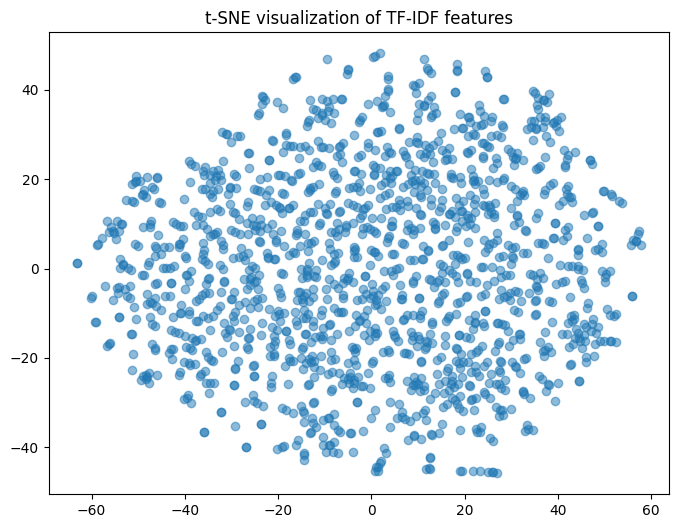

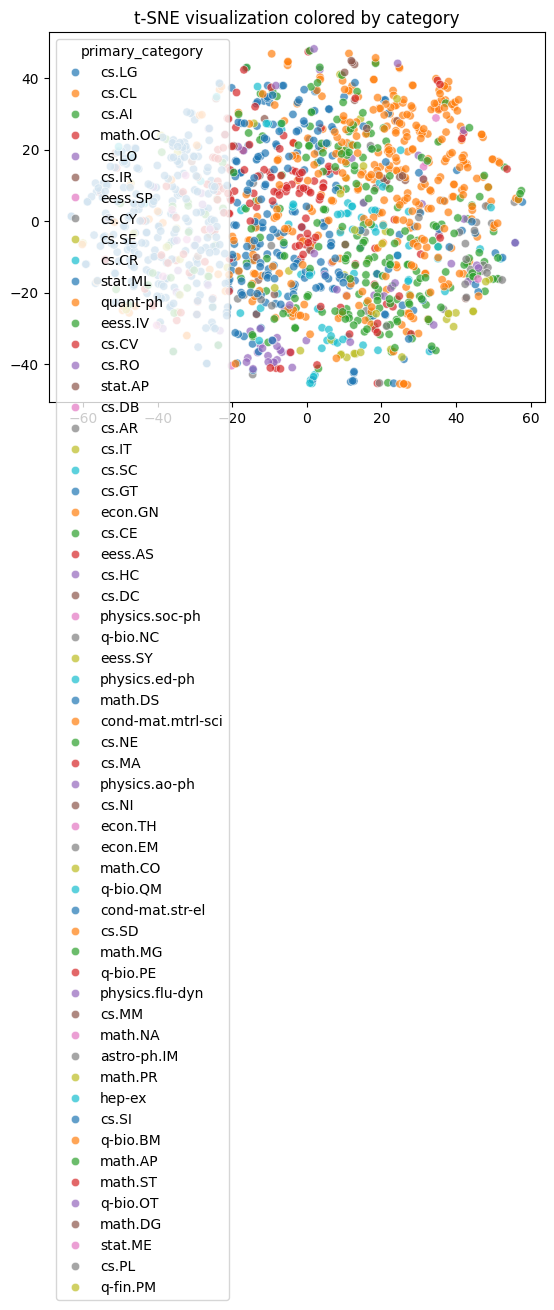

In [9]:
import matplotlib.pyplot as plt   # <-- add this line
import seaborn as sns
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.5)
plt.title("t-SNE visualization of TF-IDF features")
plt.show()


sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1],
    hue=df["primary_category"],
    palette="tab10",
    alpha=0.7
)
plt.title("t-SNE visualization colored by category")
plt.show()



## STEP 3 — Topic Modeling (Core Research Insight)

In [10]:
from sklearn.decomposition import NMF
#Brings in Non‑negative Matrix Factorization (NMF) from scikit‑learn.
#NMF is a dimensionality reduction technique often used for topic modeling in text analysis.


n_topics = 10
#Creates an NMF model with n_components=10 (i.e., 10 topics).

#random_state=42 ensures reproducibility (same results every run).


nmf = NMF(n_components=n_topics, random_state=42)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_

'''fit_transform does two things:

Learns the topic structure from the TF‑IDF matrix (X_tfidf).

Produces the document‑topic matrix W.

W has shape (n_documents, n_topics).

Each row = a document.

Each column = how strongly that document belongs to a topic.
'''

feature_names = tfidf.get_feature_names_out()

c:\Users\abc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


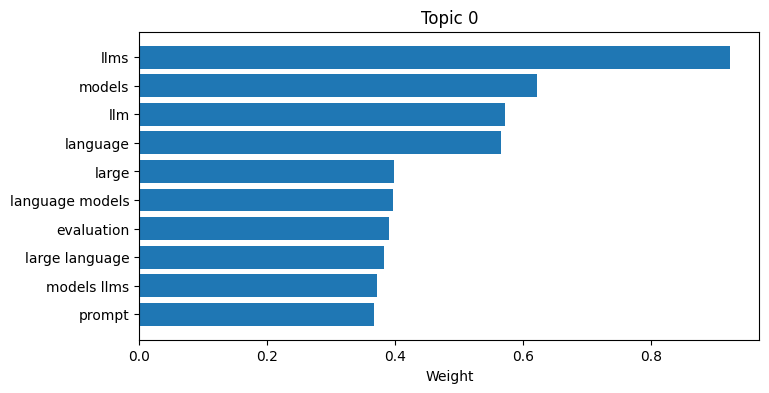

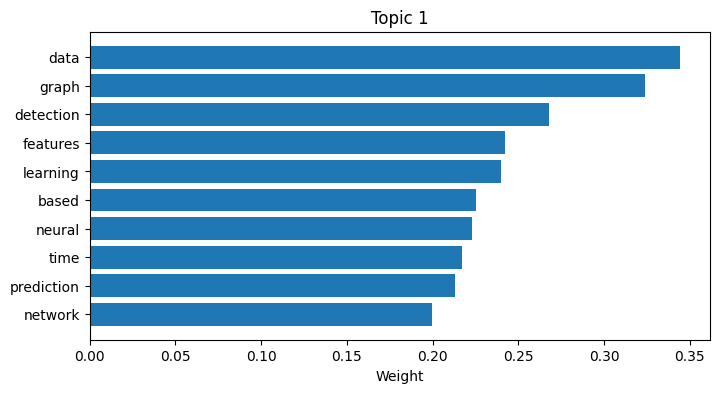

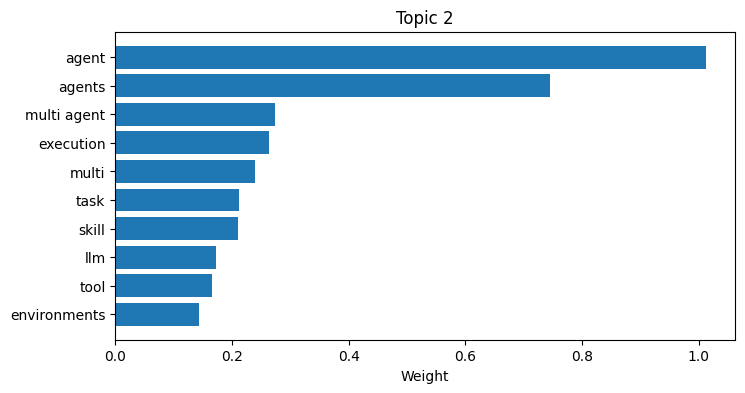

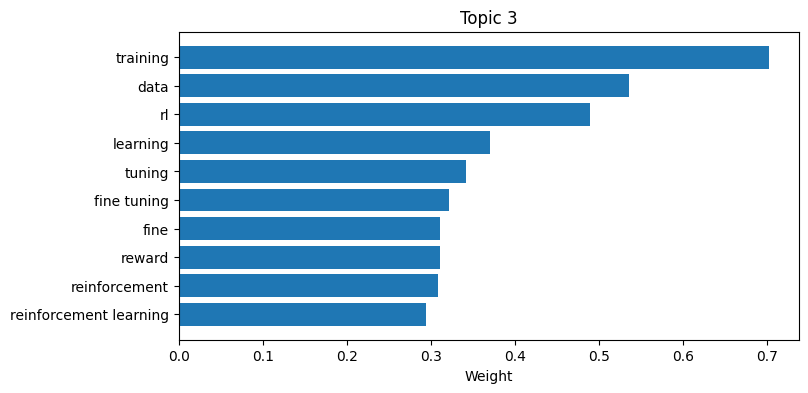

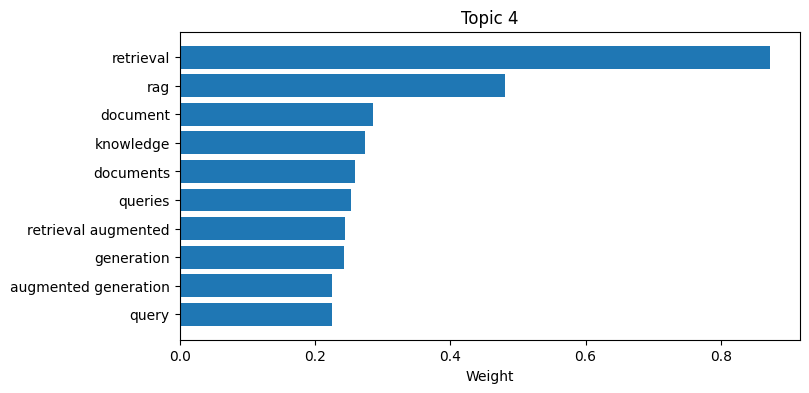

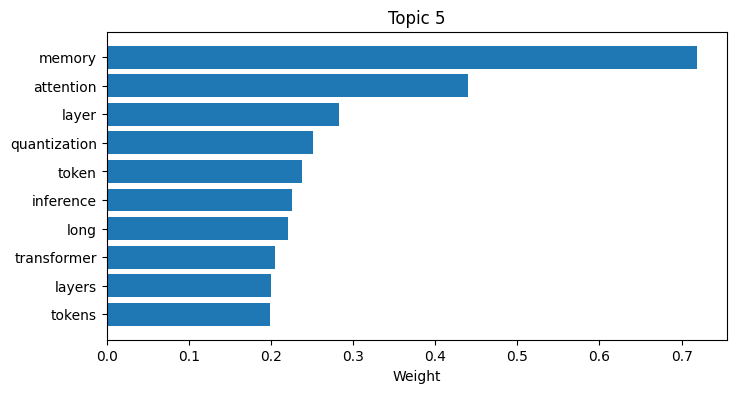

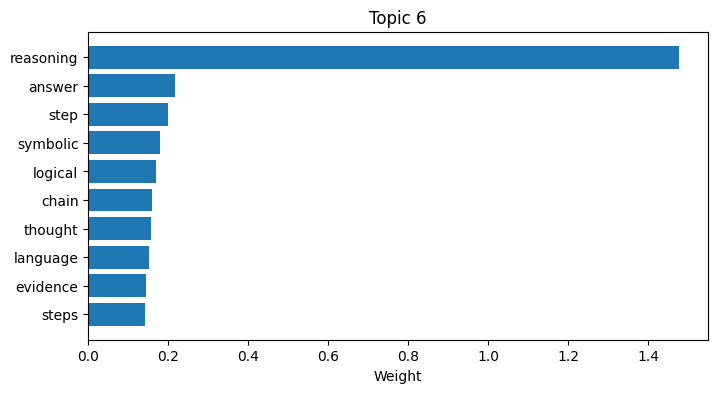

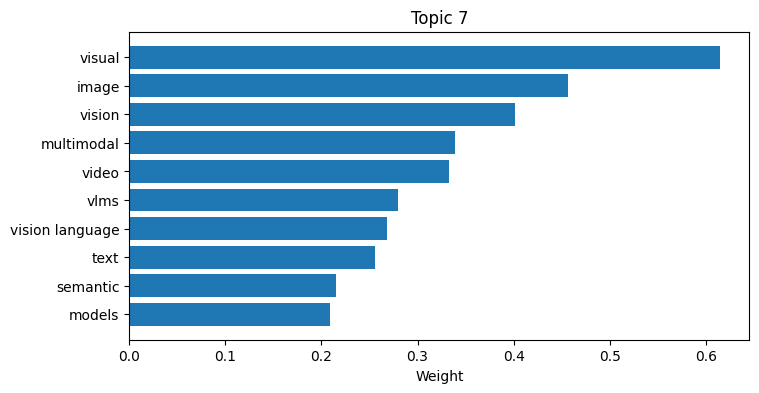

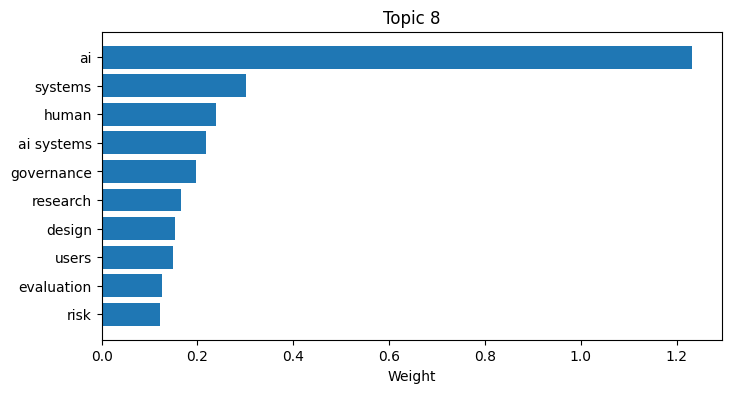

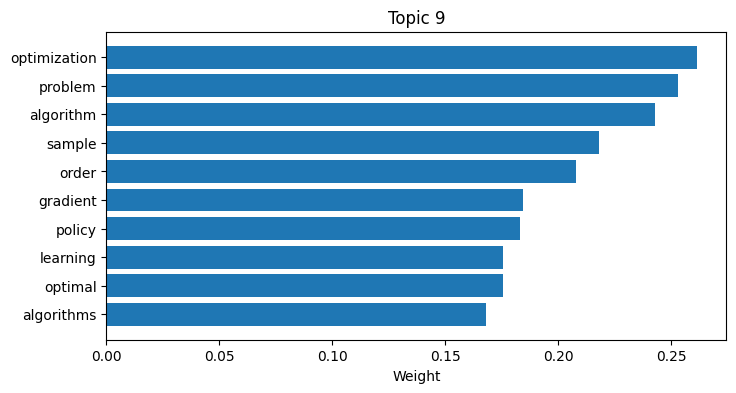

In [11]:
import matplotlib.pyplot as plt

n_top_words = 10

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[-n_top_words:]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = topic[top_indices]

    plt.figure(figsize=(8,4))
    plt.barh(top_words, top_weights)
    plt.title(f"Topic {topic_idx}")
    plt.xlabel("Weight")
    plt.show()


## Extract Topics (VERY IMPORTANT STEP)

In [12]:
'''Defines a function called display_topics.

Inputs:

H → the topic–term matrix from NMF (nmf.components_). Each row = a topic, each column = a word weight.

feature_names → the vocabulary list from TF‑IDF (tfidf.get_feature_names_out()), so we can map indices back to words.

n_top_words → how many top words to show per topic (default = 10).
'''

def display_topics(H, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[topic_idx] = top_words
        print(f"\nTopic {topic_idx}:")
        print(", ".join(top_words))
    return topics

topics = display_topics(H, feature_names)


Topic 0:
llms, models, llm, language, large, language models, evaluation, large language, models llms, prompt

Topic 1:
data, graph, detection, features, learning, based, neural, time, prediction, network

Topic 2:
agent, agents, multi agent, execution, multi, task, skill, llm, tool, environments

Topic 3:
training, data, rl, learning, tuning, fine tuning, fine, reward, reinforcement, reinforcement learning

Topic 4:
retrieval, rag, document, knowledge, documents, queries, retrieval augmented, generation, augmented generation, query

Topic 5:
memory, attention, layer, quantization, token, inference, long, transformer, layers, tokens

Topic 6:
reasoning, answer, step, symbolic, logical, chain, thought, language, evidence, steps

Topic 7:
visual, image, vision, multimodal, video, vlms, vision language, text, semantic, models

Topic 8:
ai, systems, human, ai systems, governance, research, design, users, evaluation, risk

Topic 9:
optimization, problem, algorithm, sample, order, gradient,

## STEP 4 — Assign Topic to Each Paper

In [13]:
df["topic"] = W.argmax(axis=1)

##  STEP 5 — Trend Analysis 

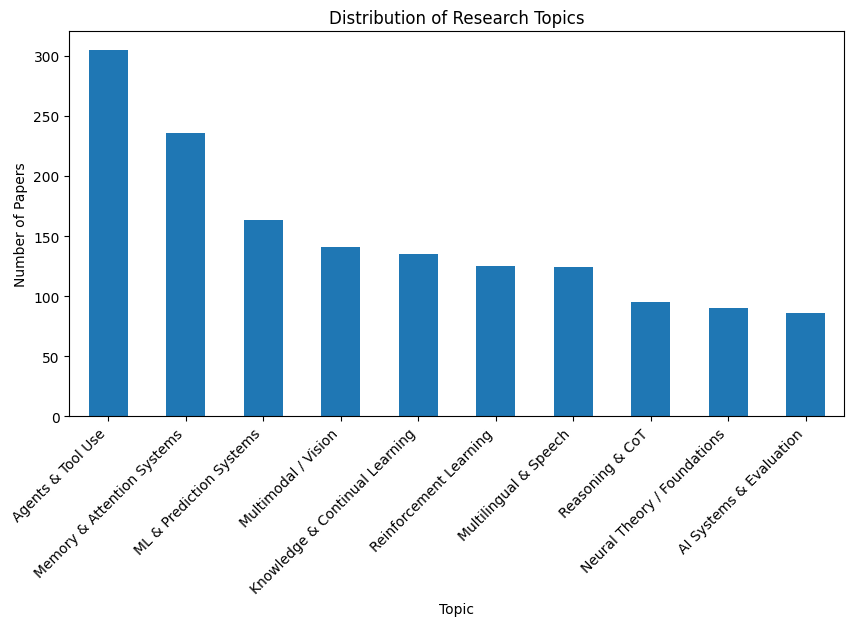

In [14]:
import matplotlib.pyplot as plt

# Example: manually assign labels based on top words
topic_labels = {
    0: "ML & Prediction Systems",
    1: "Agents & Tool Use",
    2: "Multimodal / Vision",
    3: "Reinforcement Learning",
    4: "AI Systems & Evaluation",
    5: "Multilingual & Speech",
    6: "Reasoning & CoT",
    7: "Knowledge & Continual Learning",
    8: "Neural Theory / Foundations",
    9: "Memory & Attention Systems"
}

# Replace numeric topic IDs with labels
df["topic_label"] = df["topic"].map(topic_labels)

# Count by label
topic_counts = df["topic_label"].value_counts()

# Plot with labels
plt.figure(figsize=(10,5))
topic_counts.plot(kind="bar")
plt.title("Distribution of Research Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45, ha="right")
plt.show()


## Quick Visualization

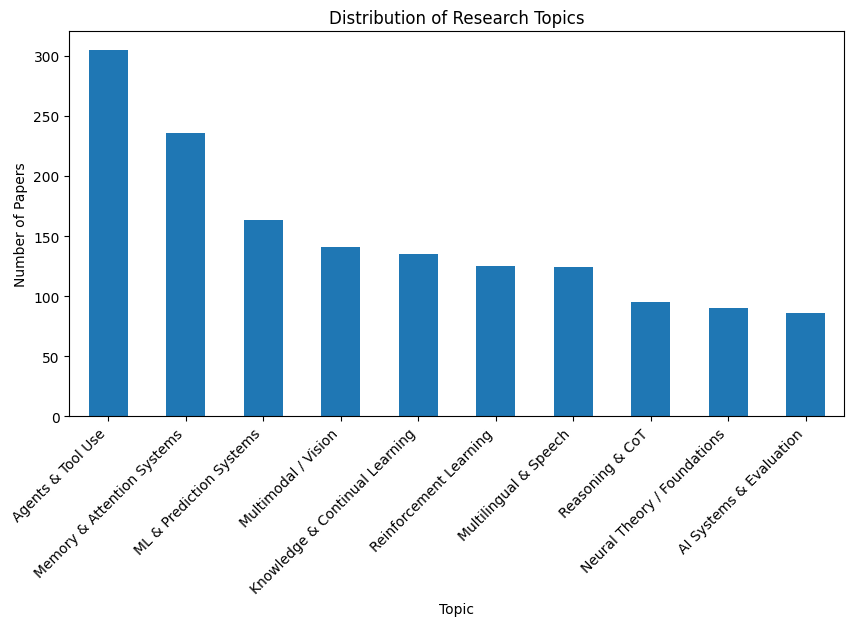

In [17]:
import matplotlib.pyplot as plt

# Example: assign descriptive names to topics
topic_labels = {
    0: "ML & Prediction Systems",
    1: "Agents & Tool Use",
    2: "Multimodal / Vision",
    3: "Reinforcement Learning",
    4: "AI Systems & Evaluation",
    5: "Multilingual & Speech",
    6: "Reasoning & CoT",
    7: "Knowledge & Continual Learning",
    8: "Neural Theory / Foundations",
    9: "Memory & Attention Systems"
}

# Add a new column with human-readable labels
df["topic_label"] = df["topic"].map(topic_labels)

# Count by label instead of numeric index
topic_counts = df["topic_label"].value_counts()

# Plot with descriptive labels
plt.figure(figsize=(10,5))
topic_counts.plot(kind="bar")
plt.title("Distribution of Research Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45, ha="right")
plt.show()


## STEP 6 — Save Enriched Dataset

In [18]:
output_path = r"C:\Users\abc\Downloads\arxiv_with_topics.csv"
df.to_csv(output_path, index=False)

# ----------------------------------------------------

# Temporal Dynamics + Emerging Trend Detection

✅ Dataset loaded: (1500, 16)

📊 Topic Distribution:
topic_label
Agents & Tool Use                 305
Memory & Attention Systems        236
ML & Prediction Systems           163
Multimodal / Vision               141
Knowledge & Continual Learning    135
Reinforcement Learning            125
Multilingual & Speech             124
Reasoning & CoT                    95
Neural Theory / Foundations        90
AI Systems & Evaluation            86
Name: count, dtype: int64

🧠 Topic Keyword Signals:

ML & Prediction Systems
[('large language', 32), ('language models', 9), ('fine tuned', 4), ('real world', 4), ('multi turn', 3), ('social media', 3), ('prior work', 3), ('llm based', 3), ('low resource', 3), ('mental health', 3)]

Agents & Tool Use
[('machine learning', 14), ('neural networks', 12), ('time series', 12), ('deep learning', 10), ('anomaly detection', 9), ('real world', 8), ('neural network', 5), ('real time', 5), ('foundation models', 4), ('physics informed', 4)]

Multimodal / Vision

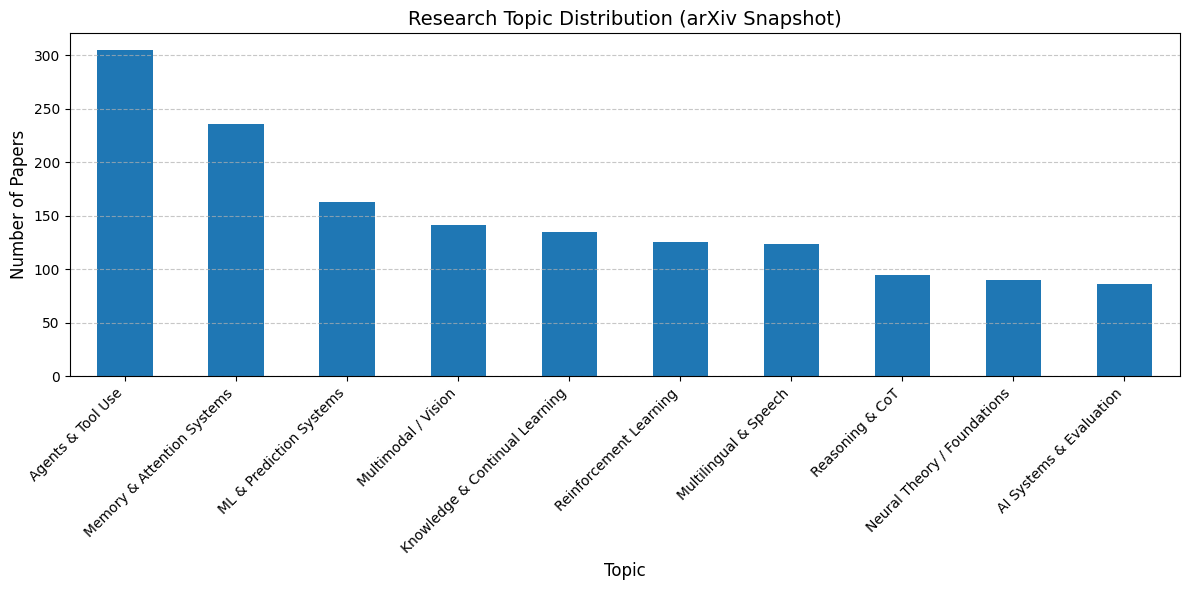


✅ Saved enriched dataset to:
C:\Users\abc\Downloads\arxiv_intelligence.csv


In [19]:
# =========================
# 0. IMPORTS
# =========================
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA (ROBUST)
# =========================
file_path = r"C:\Users\abc\Downloads\arxiv_with_topics.csv"

df = pd.read_csv(file_path, encoding="utf-8")

# =========================
# 2. SAFE PARSING (CRITICAL)
# =========================
def safe_eval(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df["keywords"] = df["keywords"].apply(safe_eval)
df["tokens"] = df["tokens"].apply(safe_eval)

# =========================
# 3. DATA VALIDATION
# =========================
assert "topic" in df.columns, "Topic column missing"
assert df.shape[0] > 0, "Empty dataset"

print("✅ Dataset loaded:", df.shape)

# =========================
# 4. HUMAN-READABLE TOPIC LABELS
# =========================
topic_labels = {
    0: "ML & Prediction Systems",
    1: "Agents & Tool Use",
    2: "Multimodal / Vision",
    3: "Reinforcement Learning",
    4: "AI Systems & Evaluation",
    5: "Multilingual & Speech",
    6: "Reasoning & CoT",
    7: "Knowledge & Continual Learning",
    8: "Neural Theory / Foundations",
    9: "Memory & Attention Systems"
}

df["topic_label"] = df["topic"].map(topic_labels)

# =========================
# 5. TOPIC DISTRIBUTION
# =========================
topic_dist = df["topic_label"].value_counts().sort_values(ascending=False)

print("\n📊 Topic Distribution:")
print(topic_dist)

# =========================
# 6. KEYWORD SIGNAL EXTRACTION
# =========================
def extract_top_keywords(df, topic_id, n=10):
    subset = df[df["topic"] == topic_id]
    keywords = []

    for row in subset["keywords"]:
        if isinstance(row, list):
            keywords.extend(row)

    return Counter(keywords).most_common(n)

print("\n🧠 Topic Keyword Signals:")
topic_keyword_map = {}

for t in sorted(df["topic"].unique()):
    top_kws = extract_top_keywords(df, t)
    topic_keyword_map[t] = top_kws

    print(f"\n{topic_labels[t]}")
    print(top_kws)

# =========================
# 7. TOP PAPERS PER TOPIC
# =========================
def get_top_papers(df, topic_id, n=5):
    subset = df[df["topic"] == topic_id]
    subset = subset.sort_values("published", ascending=False)

    return subset[["title", "authors"]].head(n)

print("\n📄 Representative Papers per Topic:")

for t in sorted(df["topic"].unique()):
    print(f"\n=== {topic_labels[t]} ===")
    print(get_top_papers(df, t).to_string(index=False))

# =========================
# 8. GLOBAL HIGH-SIGNAL PAPERS
# =========================
df["keyword_count"] = df["keywords"].apply(lambda x: len(x) if isinstance(x, list) else 0)

top_papers = df.sort_values("keyword_count", ascending=False).head(10)

print("\n🔥 High Signal Papers:")
print(top_papers[["title", "topic_label", "keyword_count"]].to_string(index=False))

# =========================
# 9. CLEAN VISUALIZATION
# =========================
plt.figure(figsize=(12,6))

topic_dist.plot(kind="bar")

plt.title("Research Topic Distribution (arXiv Snapshot)", fontsize=14)
plt.xlabel("Topic", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# =========================
# 10. SAVE FINAL DATASET
# =========================
output_path = r"C:\Users\abc\Downloads\arxiv_intelligence.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Saved enriched dataset to:\n{output_path}")

# SEMANTIC INTELLIGENCE 

We’re going to build:

✅ 1. Embeddings (true meaning, not keywords)
✅ 2. Semantic search (query → relevant papers)
✅ 3. Similar paper retrieval (paper → neighbors)
✅ 4. Trend signal layer (emerging ideas detection)

## 1. LOAD + PREP


____________________

In [21]:
import pandas as pd
import ast

file_path = r"C:\Users\abc\Downloads\arxiv_intelligence.csv"
df = pd.read_csv(file_path)

def safe_eval(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df["tokens"] = df["tokens"].apply(safe_eval)

# Combine meaningful text (IMPORTANT)
df["text"] = df["clean_title"] + " " + df["clean_summary"]
'''
Creates a new column text by concatenating the cleaned title and summary.

This gives you a single unified text field per paper, which is very useful for:

Embedding models (e.g., sentence transformers).

Topic modeling.

Classification tasks.

Search/retrieval pipelines.
'''

print("✅ Loaded:", df.shape)

✅ Loaded: (1500, 18)


## 2. EMBEDDINGS (CORE UPGRADE)

In [22]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")  # fast + strong baseline

# Generate embeddings
embeddings = model.encode(
    df["text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)
'''
df["text"].tolist() → converts your combined title+summary column into a list of strings.

model.encode() → generates a dense vector (embedding) for each text.

show_progress_bar=True → shows progress while encoding.

batch_size=32 → processes 32 texts at a time for efficiency.

'''

print("✅ Embeddings shape:", len(embeddings))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1596.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 47/47 [02:14<00:00,  2.86s/it]

✅ Embeddings shape: 1500


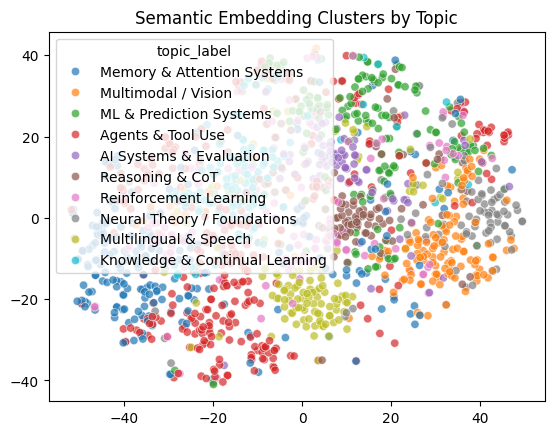

In [23]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(embeddings)

# Scatter plot colored by topic
sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1],
    hue=df["topic_label"],   # use human-readable labels
    palette="tab10",
    alpha=0.7
)
plt.title("Semantic Embedding Clusters by Topic")
plt.show()


## 3. SEMANTIC SEARCH ENGINE

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def semantic_search(query, top_k=5):
    query_emb = model.encode([query])
    #Converts the search query into an embedding vector using your SentenceTransformer model.


    scores = cosine_similarity(query_emb, embeddings)[0]
    #Computes cosine similarity between the query embedding and all paper embeddings#Higher score = more semantically similar.
    
    top_idx = np.argsort(scores)[::-1][:top_k]
    #Sorts scores in descending order and picks the indices of the top‑k most similar papers.


    results = df.iloc[top_idx][["title", "topic_label"]].copy()
    #Retrieves the titles and topic labels of those top papers from your DataFrame.


    results["score"] = scores[top_idx]
    #Adds similarity scores so you can see how close each match is.


    
    return results

# example
print(semantic_search("long context memory in LLMs", 5))

                                                  title  \
355   Spatial Metaphors for LLM Memory: A Critical A...   
1414  OPSDL: On-Policy Self-Distillation for Long-Co...   
512   SCM: Sleep-Consolidated Memory with Algorithmi...   
678   Absorber LLM: Harnessing Causal Synchronizatio...   
1292  Unlocking the Edge deployment and ondevice acc...   

                topic_label     score  
355   Multilingual & Speech  0.576105  
1414  Multilingual & Speech  0.575695  
512   Multilingual & Speech  0.568382  
678   Multilingual & Speech  0.559419  
1292  Multilingual & Speech  0.542472  


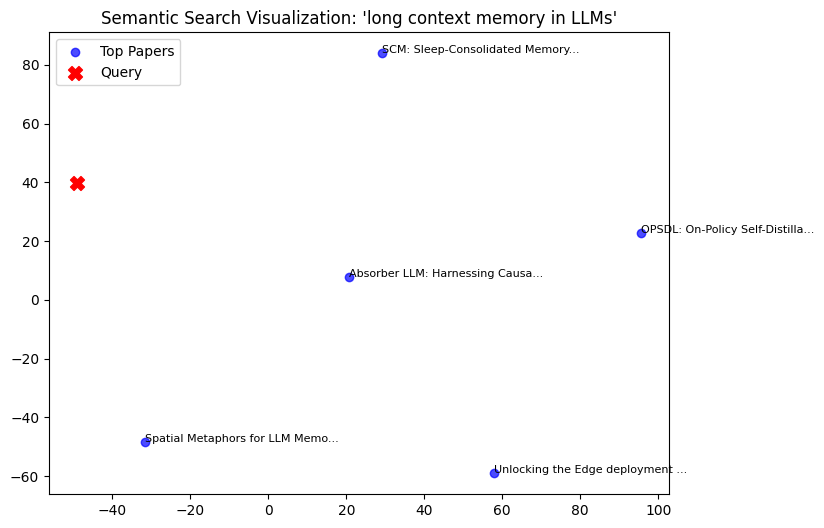

,title,topic_label,score
355,Spatial Metaphors for LLM Memory: A Critical A...,Multilingual & Speech,0.576105
1414,OPSDL: On-Policy Self-Distillation for Long-Co...,Multilingual & Speech,0.575695
512,SCM: Sleep-Consolidated Memory with Algorithmi...,Multilingual & Speech,0.568382
678,Absorber LLM: Harnessing Causal Synchronizatio...,Multilingual & Speech,0.559419
1292,Unlocking the Edge deployment and ondevice acc...,Multilingual & Speech,0.542472


In [25]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_search(query, top_k=5):
    # Run search
    results = semantic_search(query, top_k)
    
    # Get embeddings of top results + query
    query_emb = model.encode([query])
    top_embs = embeddings[results.index]
    
    combined = np.vstack([query_emb, top_embs])
    
    # Reduce to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    X_tsne = tsne.fit_transform(combined)
    
    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[1:,0], X_tsne[1:,1], c="blue", label="Top Papers", alpha=0.7)
    plt.scatter(X_tsne[0,0], X_tsne[0,1], c="red", label="Query", marker="X", s=100)
    
    for i, title in enumerate(results["title"], start=1):
        plt.text(X_tsne[i,0]+0.01, X_tsne[i,1]+0.01, title[:30]+"...", fontsize=8)
    
    plt.title(f"Semantic Search Visualization: '{query}'")
    plt.legend()
    plt.show()
    
    return results

# Example usage
visualize_search("long context memory in LLMs", 5)


## 4. SIMILAR PAPER RETRIEVAL

In [26]:
def find_similar_papers(paper_index, top_k=5):
    #Takes the embedding vector of the paper at paper_index and reshapes it into a 2D array (needed for cosine similarity).
    query_emb = embeddings[paper_index].reshape(1, -1)
    
    #Computes similarity between this paper’s embedding and all other embeddings.(from zero to one)
    scores = cosine_similarity(query_emb, embeddings)[0]
    
    '''
    Sorts scores in descending order.
    [1:top_k+1] skips the first one (which would be the paper itself, similarity = 1.0).
    Picks the next top_k most similar papers.
    '''
    top_idx = np.argsort(scores)[::-1][1:top_k+1]
    
    #Retrieves the titles and topic labels of those similar papers.
    results = df.iloc[top_idx][["title", "topic_label"]].copy()
    #Adds similarity scores to the results.
    results["score"] = scores[top_idx]
    
    return results

print(find_similar_papers(0, 5))

                                                 title  \
810  Calibrating Scientific Foundation Models with ...   
452  Adaptive Test-Time Compute Allocation with Evo...   
846  GRASPrune: Global Gating for Budgeted Structur...   
504  Tokenised Flow Matching for Hierarchical Simul...   
311  Tempered Sequential Monte Carlo for Trajectory...   

                    topic_label     score  
810       Multilingual & Speech  0.549222  
452     AI Systems & Evaluation  0.525822  
846       Multilingual & Speech  0.525135  
504  Memory & Attention Systems  0.521418  
311  Memory & Attention Systems  0.517611  


## 5. TREND SIGNAL DETECTION (VERY IMPORTANT)

In [27]:
# Convert time #Ensures the published column is treated as actual dates, not strings.

df["published"] = pd.to_datetime(df["published"])

# Recent papers (last ~30 days assumption)
recent_cutoff = df["published"].max() - pd.Timedelta(days=30)
#Keeps only papers published within the last 30 days.
recent_df = df[df["published"] >= recent_cutoff]

print("Recent papers:", recent_df.shape)

Recent papers: (1500, 18)


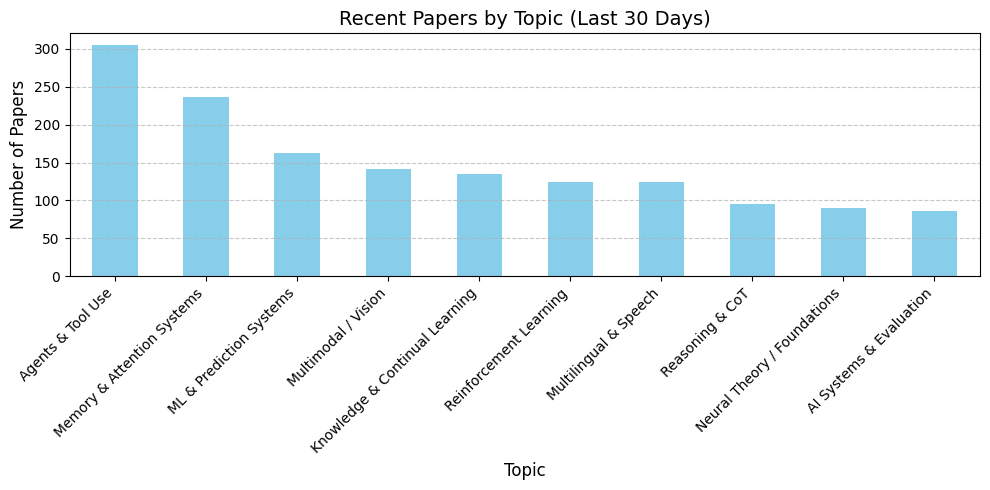

In [28]:
import matplotlib.pyplot as plt

# Count recent papers by topic
recent_topic_counts = recent_df["topic_label"].value_counts()

# Plot
plt.figure(figsize=(10,5))
recent_topic_counts.plot(kind="bar", color="skyblue")

plt.title("Recent Papers by Topic (Last 30 Days)", fontsize=14)
plt.xlabel("Topic", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## 6. EMERGING CLUSTER DETECTION

In [32]:
from sklearn.cluster import KMeans

k = 8  # tunable

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(embeddings)

df["cluster"] = clusters

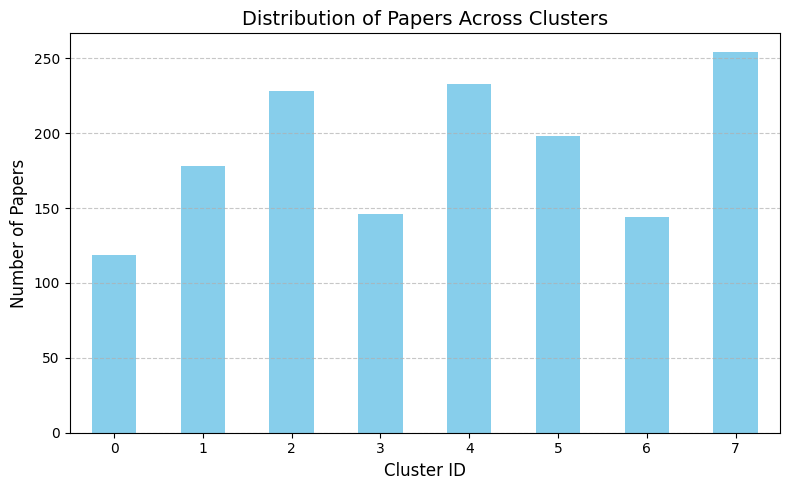

In [33]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar", color="skyblue")

plt.title("Distribution of Papers Across Clusters", fontsize=14)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


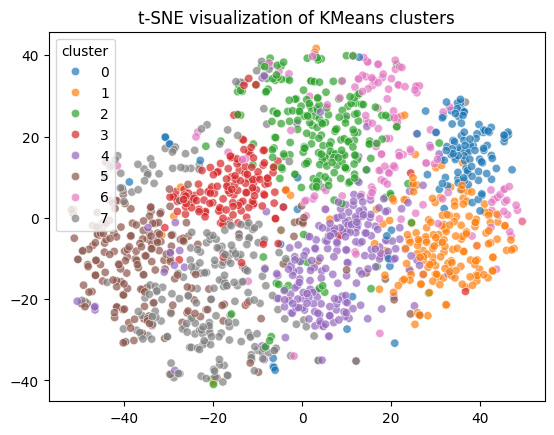

In [34]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(embeddings)

sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1],
    hue=df["cluster"],
    palette="tab10",
    alpha=0.7
)
plt.title("t-SNE visualization of KMeans clusters")
plt.show()


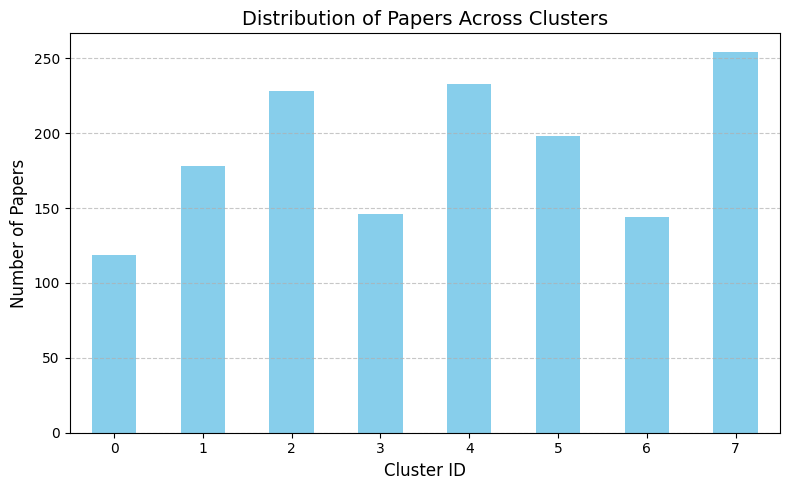

In [35]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar", color="skyblue")

plt.title("Distribution of Papers Across Clusters", fontsize=14)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## 8. SAVE ENRICHED DATASET

In [36]:
output_path = r"C:\Users\abc\Downloads\arxiv_semantic_intelligence.csv"
df.to_csv(output_path, index=False)

print("✅ Saved:", output_path)

✅ Saved: C:\Users\abc\Downloads\arxiv_semantic_intelligence.csv


# RESEARCH AGENT SYSTEM (FULL, END-TO-END)

🧠 Capabilities

Auto-extract core contributions

Identify method / problem / improvement

Compute novelty score

Compute impact score

Rank must-read papers

Generate research insights per cluster

In [37]:
# =========================================
# PHASE 5 — RESEARCH AGENT SYSTEM
# =========================================

import pandas as pd
import numpy as np
import re
import ast
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

# =========================================
# 1. LOAD DATA
# =========================================
file_path = r"C:\Users\abc\Downloads\arxiv_semantic_intelligence.csv"
df = pd.read_csv(file_path)

# =========================================
# 2. SAFE PARSE
# =========================================
def safe_eval(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df["tokens"] = df["tokens"].apply(safe_eval)

# =========================================
# 3. TEXT NORMALIZATION
# =========================================
df["text"] = df["clean_title"] + " " + df["clean_summary"]

# =========================================
# 4. CONTRIBUTION EXTRACTION (RULE-BASED NLP)
# =========================================


'''
Uses regex patterns to detect phrases like “we introduce…” or “we propose…” to extract the main contribution.

'''
def extract_contribution(text):
    text = text.lower()
    
    patterns = [
        r"we introduce (.+?)[\.\,]",
        r"we propose (.+?)[\.\,]",
        r"we present (.+?)[\.\,]",
        r"this paper introduces (.+?)[\.\,]",
        r"this work proposes (.+?)[\.\,]"
    ]
    
    for p in patterns:
        match = re.search(p, text)
        if match:
            return match.group(1)
    
    return "unknown"

df["contribution"] = df["text"].apply(extract_contribution)

# =========================================
# 5. METHOD / PROBLEM / IMPROVEMENT EXTRACTION
# =========================================

def extract_signal(text):
    text = text.lower()
    
    method = None
    problem = None
    improvement = None
    
    if "we introduce" in text or "we propose" in text:
        method = extract_contribution(text)
    
    if "problem" in text or "challenge" in text:
        problem = "identified problem"
    
    if "improve" in text or "outperform" in text:
        improvement = "performance improvement"
    
    return method, problem, improvement

df[["method", "problem", "improvement"]] = df["text"].apply(
    lambda x: pd.Series(extract_signal(x))
)

# =========================================
# 6. NOVELTY SCORE (SEMANTIC DISTANCE)
# =========================================

'''Loads embeddings (or regenerates them).

Computes the centroid of all embeddings.

Measures cosine similarity to the centroid → papers farther away are considered more “novel.”

Stores novelty as 1 - similarity.
'''
# Load embeddings from previous phase if available
try:
    import pickle
    with open("embeddings.pkl", "rb") as f:
        embeddings = pickle.load(f)
except:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

# Compute centroid
centroid = np.mean(embeddings, axis=0).reshape(1, -1)

# Distance from centroid = novelty
novelty_scores = cosine_similarity(embeddings, centroid).flatten()

df["novelty_score"] = 1 - novelty_scores

# =========================================
# 7. IMPACT SCORE
# =========================================

def compute_impact(row):
    score = 0
    
    text = row["text"]
    
    if "benchmark" in text:
        score += 2
    if "state of the art" in text or "sota" in text:
        score += 3
    if "outperform" in text:
        score += 2
    if "large scale" in text:
        score += 1
    if "open source" in text:
        score += 1
    
    return score

df["impact_score"] = df.apply(compute_impact, axis=1)

# =========================================
# 8. COMBINED RESEARCH SCORE
# =========================================

df["research_score"] = (
    0.6 * df["novelty_score"] +
    0.4 * (df["impact_score"] / df["impact_score"].max())
)

# =========================================
# 9. TOP PAPERS (GLOBAL)
# =========================================

top_papers = df.sort_values("research_score", ascending=False).head(20)

print("\n🔥 TOP RESEARCH PAPERS:")
print(top_papers[["title", "topic_label", "research_score"]].to_string(index=False))

# =========================================
# 10. CLUSTER INSIGHT GENERATION
# =========================================

def generate_cluster_insight(cluster_id):
    subset = df[df["cluster"] == cluster_id]
    
    words = []
    for tokens in subset["tokens"]:
        words.extend(tokens)
    
    top_words = [w for w, _ in Counter(words).most_common(10)]
    
    return ", ".join(top_words)

cluster_insights = {}

for c in sorted(df["cluster"].unique()):
    cluster_insights[c] = generate_cluster_insight(c)

print("\n🧠 CLUSTER INSIGHTS:")
for c, insight in cluster_insights.items():
    print(f"Cluster {c}: {insight}")

# =========================================
# 11. MUST-READ PER TOPIC
# =========================================

print("\n📚 MUST-READ PAPERS PER TOPIC:")

for topic in df["topic_label"].unique():
    subset = df[df["topic_label"] == topic]
    best = subset.sort_values("research_score", ascending=False).head(3)
    
    print(f"\n=== {topic} ===")
    print(best[["title", "research_score"]].to_string(index=False))

# =========================================
# 12. SAVE FINAL INTELLIGENCE DATASET
# =========================================

output_path = r"C:\Users\abc\Downloads\arxiv_research_agent.csv"
df.to_csv(output_path, index=False)

print("\n✅ FINAL DATASET SAVED:", output_path)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3268.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 47/47 [02:55<00:00,  3.74s/it]



🔥 TOP RESEARCH PAPERS:
                                                                                                                           title                    topic_label  research_score
                                             Decoding High-Dimensional Finger Motion from EMG Using Riemannian Features and RNNs              Agents & Tool Use        0.691353
               Robustness of Spatio-temporal Graph Neural Networks for Fault Location in Partially Observable Distribution Grids              Agents & Tool Use        0.675785
                                                  EEG-Based Emergency Braking Intensity Prediction Using Blind Source Separation              Agents & Tool Use        0.672386
                                  F\textsuperscript{2}LP-AP: Fast \& Flexible Label Propagation with Adaptive Propagation Kernel              Agents & Tool Use        0.670433
                                                                               Towards Real-Time

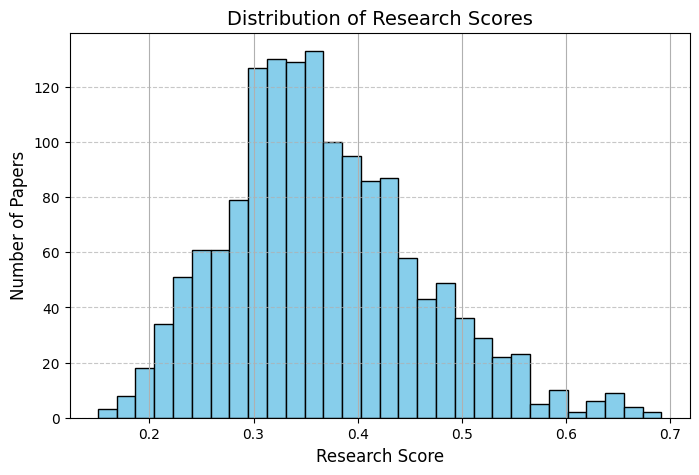

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["research_score"].hist(bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Research Scores", fontsize=14)
plt.xlabel("Research Score", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



# VISUALIZATION + LLM AGENT (ONE GO)

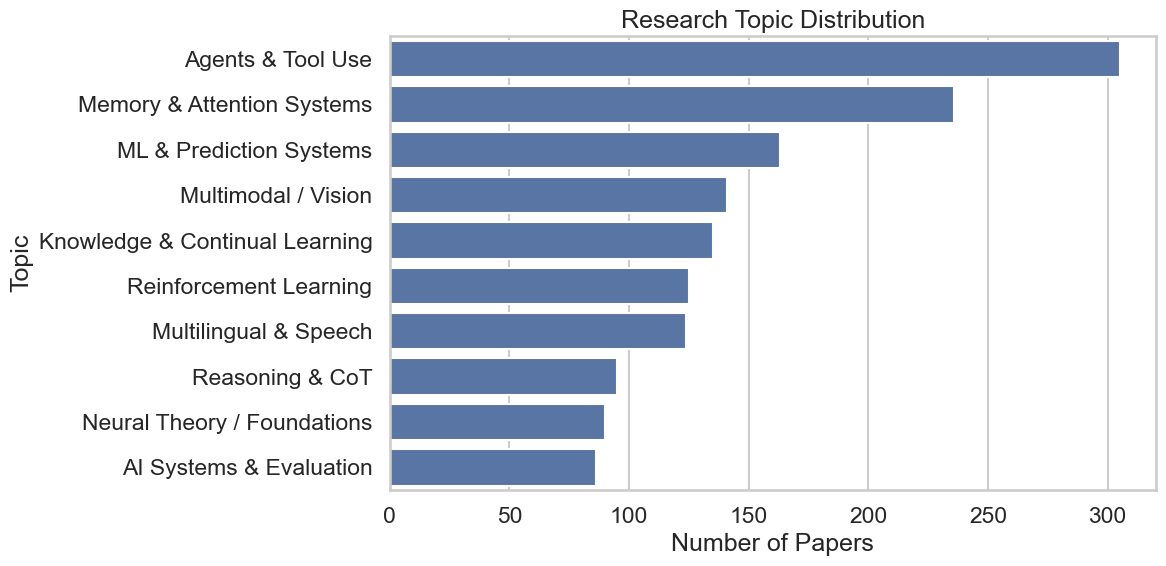

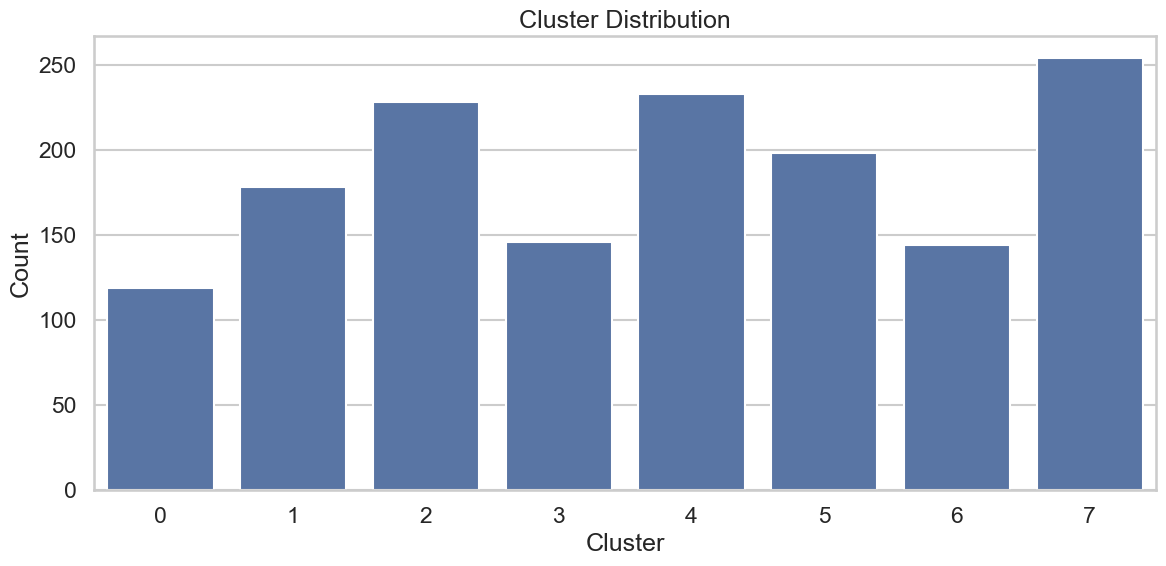

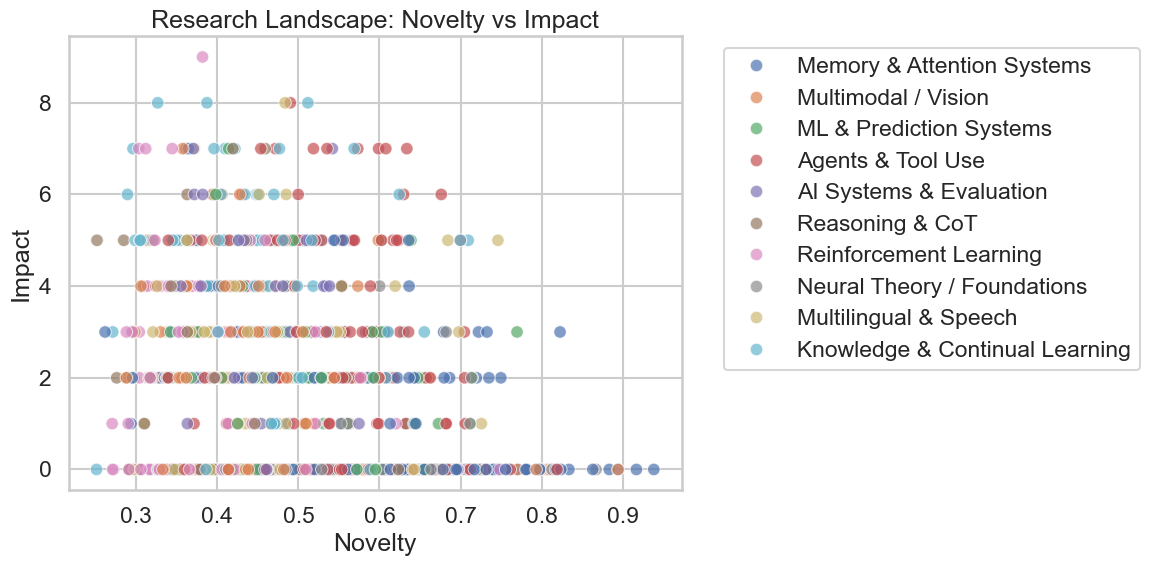

C:\Users\abc\AppData\Local\Temp\ipykernel_2024\314289281.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


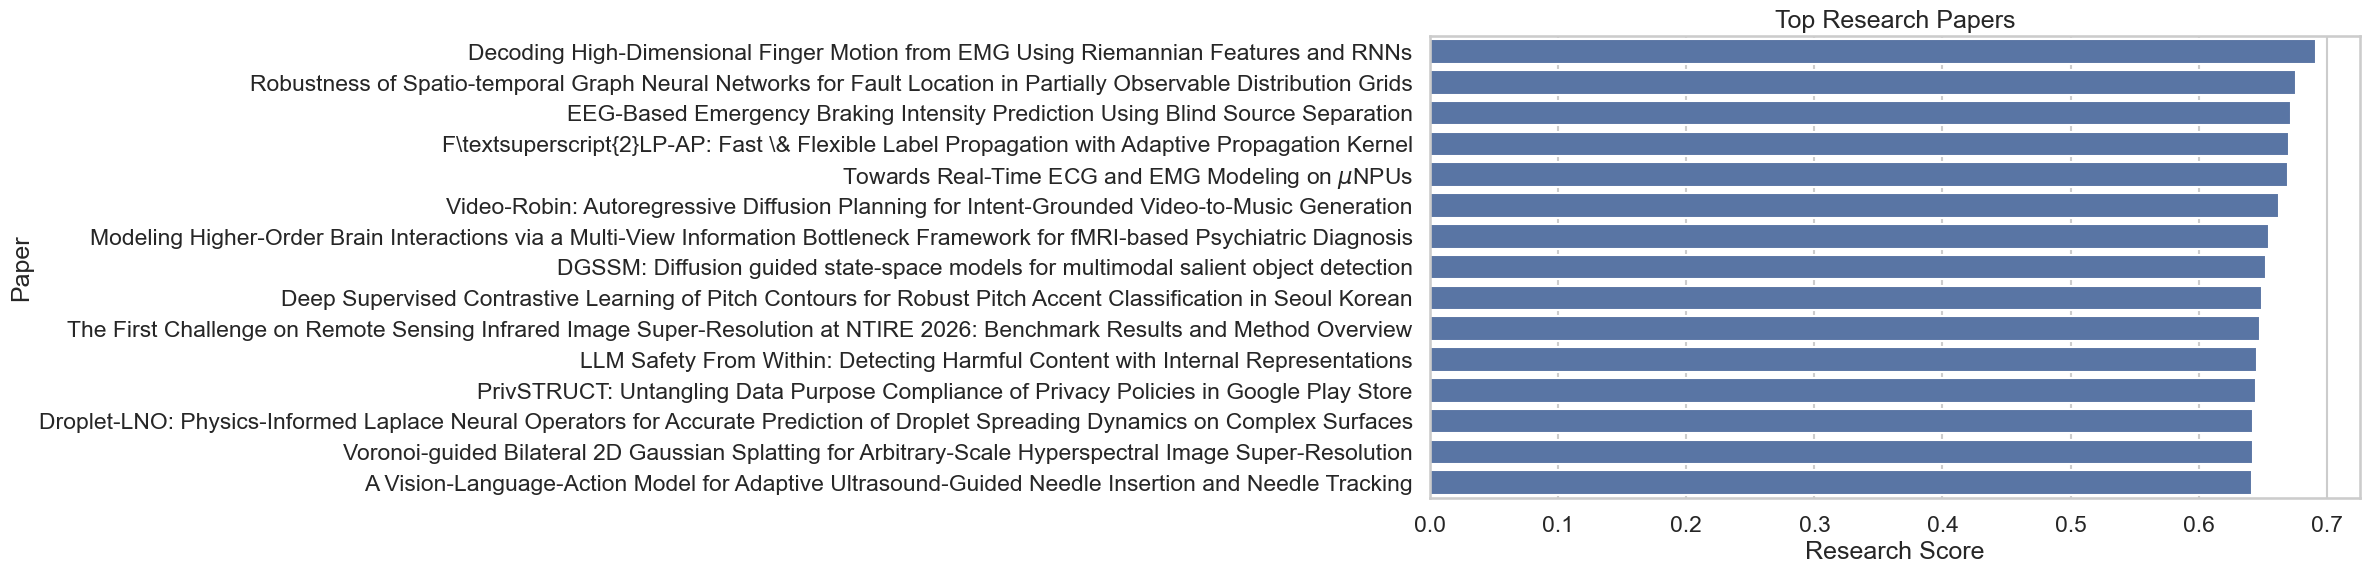

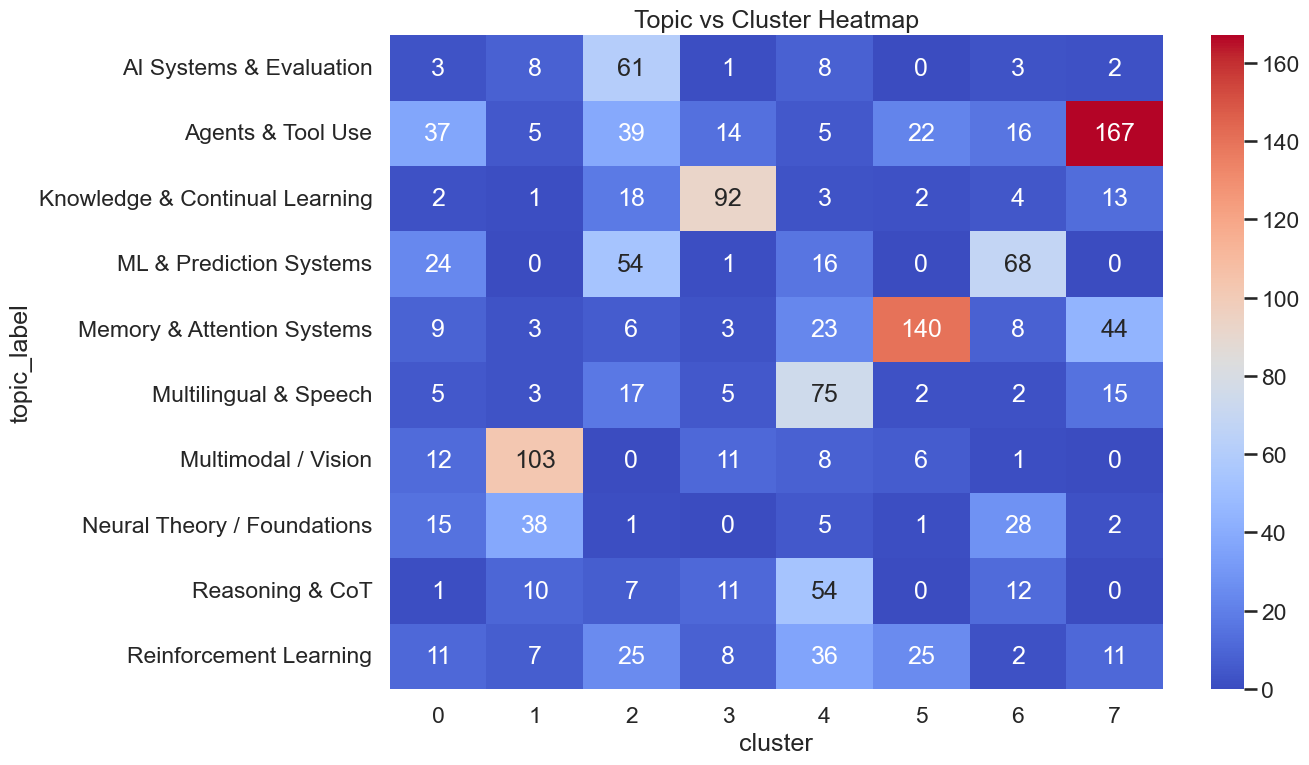

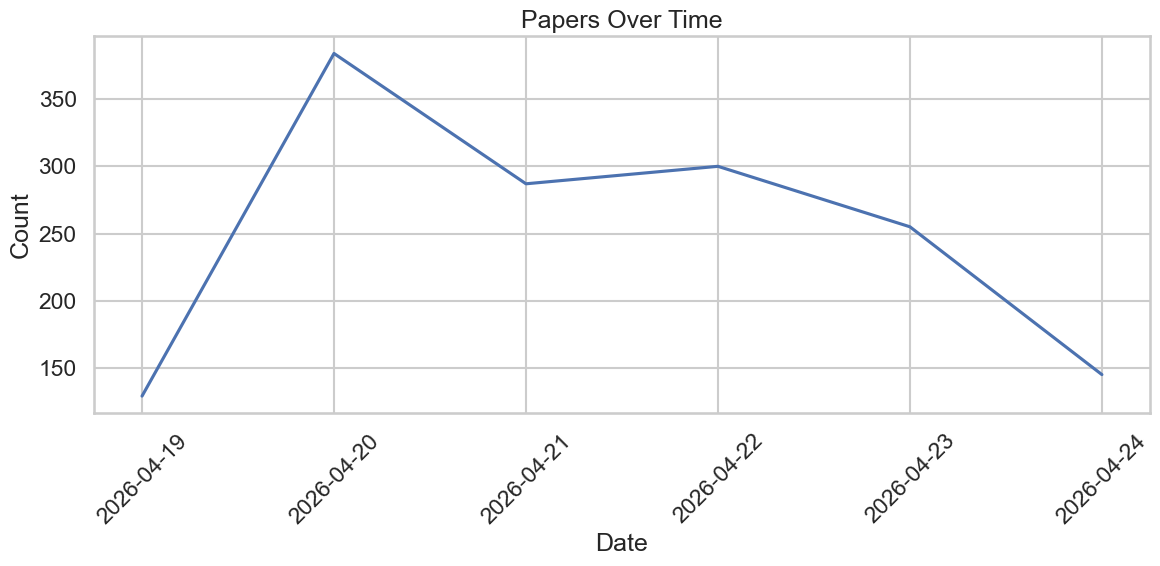


🚀 FRONTIER PAPERS:
                                                                                                                           title                    topic_label  novelty_score  impact_score
                                             Decoding High-Dimensional Finger Motion from EMG Using Riemannian Features and RNNs              Agents & Tool Use       0.633737             7
                                         PrivSTRUCT: Untangling Data Purpose Compliance of Privacy Policies in Google Play Store              Agents & Tool Use       0.629789             6
                                                                    Call-Chain-Aware LLM-Based Test Generation for Java Projects        ML & Prediction Systems       0.601404             5
                                      A Green-Integral-Constrained Neural Solver with Stochastic Physics-Informed Regularization     Memory & Attention Systems       0.636560             4
                                   

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 1239.01it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxFo


🧠 LLM RESEARCH INSIGHTS:


=== Decoding High-Dimensional Finger Motion from EMG Using Riemannian Features and RNNs ===


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    Analyze this research paper and extract:
    1. Main contribution
    2. Problem it solves
    3. Key method
    4. Why it matters

    Paper:
    decoding high dimensional finger motion from emg using riemannian features and rnns continuous estimation of high dimensional finger kinematics from forearm surface electromyography emg could enable natural control for hand prostheses ar xr interfaces and teleoperation however the complexity of human hand gestures and the entanglement of forearm muscles make accurate recognition intrinsically challenging existing approaches typically reduce task complexity by relying on classification based machine learning limiting the controllable degrees of freedom and compromising on natural interaction we present an end to end framework for continuous emg to kinematics regression using only consumer grade hardware the framework combines an channel emg armband a single webcam and an automatic synchronization procedure enabling the collection of the 

...


    Analyze this research paper and extract:
    1. Main contribution
    2. Problem it solves
    3. Key method
    4. Why it matters

    Paper:
    eeg based emergency braking intensity prediction using blind source separation electroencephalography eeg signals have been promising for long term braking intensity prediction but are prone to various artifacts that limit their reliability here we propose a novel framework that models eeg signals as mixtures of independent blind sources and identifies those strongly correlated with braking action our method employs independent component analysis to decompose eeg into different components and combines time frequency analysis with pearson correlations to select braking related components furthermore we utilize hierarchical clustering to group braking related components into two clusters each characterized by a distinct spatial pattern additionally these components exhibit trial invariant temporal patterns and demonstrate stable and commo

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    Analyze this research paper and extract:
    1. Main contribution
    2. Problem it solves
    3. Key method
    4. Why it matters

    Paper:
    f textsuperscript lp ap fast flexible label propagation with adaptive propagation kernel semi supervised node classification is a foundational task in graph machine learning yet state of the art graph neural networks gnns are hindered by significant computational overhead and reliance on strong homophily assumptions traditional gnns require expensive iterative training and multi layer message passing while existing training free methods such as label propagation lack adaptability to heterophilo us graph structures this paper presents textbf f lp ap fast and flexible label propagation with adaptive propagation kernel a training free computationally efficient framework that adapts to local graph topology our method constructs robust class prototypes via the geometric median and dynamically adjusts propagation parameters based on the local

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    Analyze this research paper and extract:
    1. Main contribution
    2. Problem it solves
    3. Key method
    4. Why it matters

    Paper:
    towards real time ecg and emg modeling on npus the miniaturisation of neural processing units npus and other low power accelerators has enabled their integration into microcontroller scale wearable hardware supporting near real time offline and privacy preserving inference yet physiological signal analysis has remained infeasible on such hardware recent transformer based models show state of the art performance but are prohibitively large for resource and power constrained hardware and incompatible with npus due to their dynamic attention operations we introduce physiolite a lightweight npu compatible model architecture and training framework for ecg emg signal analysis using learnable wavelet filter banks cpu offloaded positional encoding and hardware aware layer design physiolite reaches performance comparable to state of the art tran

In [40]:
# =========================================
# PHASE 6 — VISUALIZATION + LLM RESEARCH AGENT
# =========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 1. LOAD DATA
# =========================================
file_path = r"C:\Users\abc\Downloads\arxiv_research_agent.csv"
df = pd.read_csv(file_path)

# Clean datetime
df["published"] = pd.to_datetime(df["published"])

# Style (IMPORTANT)
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

# =========================================
# 2. TOPIC DISTRIBUTION
# =========================================
plt.figure()
topic_counts = df["topic_label"].value_counts()

sns.barplot(
    x=topic_counts.values,
    y=topic_counts.index
)

plt.title("Research Topic Distribution")
plt.xlabel("Number of Papers")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# =========================================
# 3. CLUSTER DISTRIBUTION
# =========================================
plt.figure()
sns.countplot(data=df, x="cluster")

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================
# 4. NOVELTY vs IMPACT (KEY GRAPH)
# =========================================
plt.figure()

sns.scatterplot(
    data=df,
    x="novelty_score",
    y="impact_score",
    hue="topic_label",
    alpha=0.7
)

plt.title("Research Landscape: Novelty vs Impact")
plt.xlabel("Novelty")
plt.ylabel("Impact")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# =========================================
# 5. TOP PAPERS (RESEARCH SCORE)
# =========================================
top = df.sort_values("research_score", ascending=False).head(15)

plt.figure()

sns.barplot(
    data=top,
    x="research_score",
    y="title"
)

plt.title("Top Research Papers")
plt.xlabel("Research Score")
plt.ylabel("Paper")
plt.tight_layout()
plt.show()

# =========================================
# 6. HEATMAP (TOPIC vs CLUSTER)
# =========================================
pivot = pd.crosstab(df["topic_label"], df["cluster"])

plt.figure(figsize=(14,8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="coolwarm")

plt.title("Topic vs Cluster Heatmap")
plt.tight_layout()
plt.show()

# =========================================
# 7. TIME TREND
# =========================================
df["date"] = df["published"].dt.date

trend = df.groupby("date").size()

plt.figure()
sns.lineplot(x=trend.index, y=trend.values)

plt.title("Papers Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================
# 8. ADVANCED: FRONTIER PAPERS (HIGH NOVELTY + IMPACT)
# =========================================
frontier = df[
    (df["novelty_score"] > df["novelty_score"].quantile(0.8)) &
    (df["impact_score"] > df["impact_score"].quantile(0.8))
]

print("\n🚀 FRONTIER PAPERS:")
print(frontier[["title", "topic_label", "novelty_score", "impact_score"]].to_string(index=False))

# =========================================
# 9. LLM-POWERED RESEARCH AGENT
# =========================================

from transformers import pipeline

# lightweight local model (no API needed)
summarizer = pipeline("text-generation", model="google/flan-t5-base")

def analyze_paper(text):
    prompt = f"""
    Analyze this research paper and extract:
    1. Main contribution
    2. Problem it solves
    3. Key method
    4. Why it matters

    Paper:
    {text[:1000]}
    """
    
    result = summarizer(prompt, max_length=200, do_sample=False)
    return result[0]["generated_text"]

# Apply to top papers only (efficiency)
top_papers = df.sort_values("research_score", ascending=False).head(5)

print("\n🧠 LLM RESEARCH INSIGHTS:\n")

for i, row in top_papers.iterrows():
    print(f"\n=== {row['title']} ===")
    insight = analyze_paper(row["text"])
    print(insight)

# =========================================
# 10. SAVE FINAL ENRICHED DATA
# =========================================
output_path = r"C:\Users\abc\Downloads\arxiv_final_visualized.csv"
df.to_csv(output_path, index=False)

print("\n✅ FINAL VISUAL + LLM DATASET SAVED:", output_path)